# Car Price Prediction with Machine Learning

## Project Introduction

This notebook aims to develop a machine learning model to accurately predict the selling price of used cars. By leveraging various car features, we will build and evaluate regression models to assist both buyers and sellers in the used car market.

### Dataset Description

The dataset used for this project is titled `CAR DETAILS FROM CAR DEKHO.csv`. It contains information about various cars, including their attributes and corresponding selling prices. We will explore this dataset to understand its characteristics, clean it, engineer relevant features, and finally, train predictive models.

## 1. Import Libraries

We begin by importing all the necessary Python libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

Now, we will load the `CAR DETAILS FROM CAR DEKHO.csv` file into a pandas DataFrame and display its first and last few rows to get an initial glimpse of the data.

In [2]:
# Load the dataset
df = pd.read_csv('/content/CAR DETAILS FROM CAR DEKHO.csv')

print("First 5 rows of the dataset:")
display(df.head())

print("\nLast 5 rows of the dataset:")
display(df.tail())

First 5 rows of the dataset:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner



Last 5 rows of the dataset:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner
4339,Renault KWID RXT,2016,225000,40000,Petrol,Individual,Manual,First Owner


## 3. Exploratory Data Analysis (EDA)

In this section, we will perform a detailed Exploratory Data Analysis to understand the dataset's characteristics, identify patterns, and prepare for data cleaning and feature engineering.

### 3.1 Dataset Shape

Let's check the number of rows and columns in our dataset.

In [3]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset has 4340 rows and 8 columns.


### 3.2 Dataset Information

We will get a concise summary of the DataFrame, including the number of non-null values and data types for each column.

In [4]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


### 3.3 Data Types

Let's examine the data types of each column to ensure they are appropriate for analysis.

In [5]:
print("\nData Types:")
print(df.dtypes)


Data Types:
name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object


### 3.4 Missing Values

We will check for any missing values in the dataset and visualize their distribution.


Missing Values:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


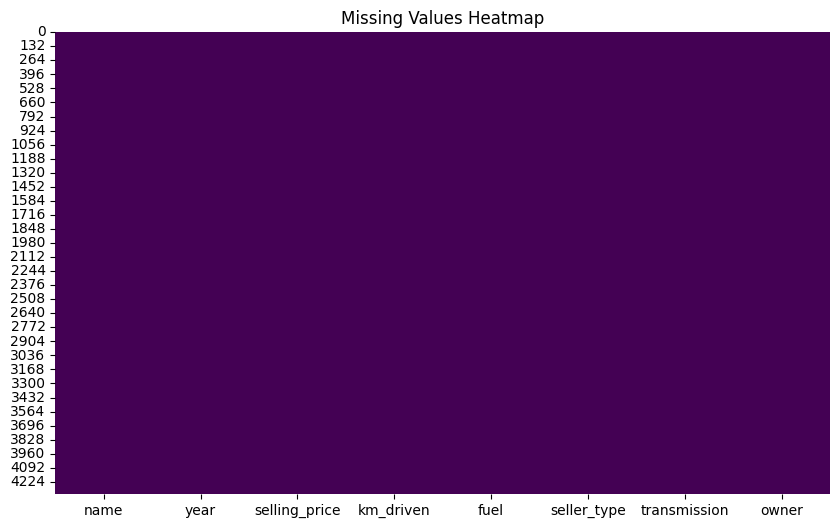

In [6]:
print("\nMissing Values:")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Percentage': missing_percentage})
print(missing_df[missing_df['Missing Count'] > 0])

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### 3.5 Duplicate Values

Identifying and handling duplicate entries is crucial for data quality.

In [7]:
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())


Number of Duplicate Rows:
763


### 3.6 Statistical Summary

We will generate descriptive statistics for numerical columns to understand their distribution.

In [8]:
print("\nStatistical Summary of Numerical Columns:")
display(df.describe())


Statistical Summary of Numerical Columns:


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


### 3.7 Unique Values of Categorical Columns

Let's inspect the unique values and their counts for all categorical columns to identify potential inconsistencies or rare categories.

In [9]:
print("\nUnique Values of Categorical Columns:")
for col in df.select_dtypes(include='object').columns:
    print(f"\nColumn '{col}':")
    print(df[col].value_counts())
    print("-" * 30)


Unique Values of Categorical Columns:

Column 'name':
name
Maruti Swift Dzire VDI                            69
Maruti Alto 800 LXI                               59
Maruti Alto LXi                                   47
Hyundai EON Era Plus                              35
Maruti Alto LX                                    35
                                                  ..
Honda Brio 1.2 S Option MT                         1
Mahindra Bolero Power Plus Plus Non AC BSIV PS     1
Tata Indigo LS BSII                                1
Force One EX                                       1
Chevrolet Aveo 1.4 LT BSIV                         1
Name: count, Length: 1491, dtype: int64
------------------------------

Column 'fuel':
fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
------------------------------

Column 'seller_type':
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, 

## 4. Data Cleaning

Data cleaning is an essential step to prepare the dataset for machine learning. We will handle duplicates, missing values, and potential inconsistencies in categorical features.

### 4.1 Remove Duplicates

We identified duplicate rows during EDA. Let's remove them to prevent biased model training.

In [10]:
print(f"Number of rows before removing duplicates: {df.shape[0]}")
df.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {df.shape[0]}")

Number of rows before removing duplicates: 4340
Number of rows after removing duplicates: 3577


### 4.2 Handle Missing Values

Based on our EDA, there were no missing values. However, it's good practice to include this step. If any were present, we would address them here, for example, by imputation or removal.

In [11]:
print("Missing values after dropping duplicates:")
print(df.isnull().sum()[df.isnull().sum() > 0])

if df.isnull().sum().sum() == 0:
    print("No missing values found after cleaning.")
else:
    # Example of how to handle missing values if they were present
    # For numerical columns, you might impute with median/mean:
    # for col in df.select_dtypes(include=np.number).columns:
    #     if df[col].isnull().any():
    #         df[col].fillna(df[col].median(), inplace=True)
    # For categorical columns, you might impute with mode or a new category:
    # for col in df.select_dtypes(include='object').columns:
    #     if df[col].isnull().any():
    #         df[col].fillna(df[col].mode()[0], inplace=True)
    print("Missing values handled (if any were present).")

Missing values after dropping duplicates:
Series([], dtype: int64)
No missing values found after cleaning.


### 4.3 Correct Inconsistent Categorical Values

We will re-examine the unique values of categorical columns to ensure there are no inconsistencies that were not apparent during the initial EDA. For now, based on the initial `value_counts()` outputs, the categorical columns (`fuel`, `seller_type`, `transmission`, `owner`) seem consistent. If any issues were found (e.g., 'petrol' and 'Petrol'), we would standardize them here.

In [12]:
print("Re-checking unique values of categorical columns for inconsistencies:")
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\nColumn '{col}':")
    print(df[col].value_counts())
    print("-" * 30)

print("No major inconsistencies found in categorical columns based on visual inspection. If any were found, they would be standardized here.")

Re-checking unique values of categorical columns for inconsistencies:

Column 'name':
name
Maruti Swift Dzire VDI        54
Maruti Alto 800 LXI           48
Maruti Alto LXi               42
Maruti Alto LX                30
Maruti Swift VDI BSIV         28
                              ..
Tata Indica V2 DLS BSII        1
Mahindra XUV500 W10 AWD        1
Toyota Fortuner 2.7 2WD AT     1
Fiat Punto EVO 1.3 Emotion     1
Nissan Terrano XE 85 PS        1
Name: count, Length: 1491, dtype: int64
------------------------------

Column 'fuel':
fuel
Diesel      1800
Petrol      1717
CNG           37
LPG           22
Electric       1
Name: count, dtype: int64
------------------------------

Column 'seller_type':
seller_type
Individual          2832
Dealer               712
Trustmark Dealer      33
Name: count, dtype: int64
------------------------------

Column 'transmission':
transmission
Manual       3265
Automatic     312
Name: count, dtype: int64
------------------------------

Column 'owner'

### 4.4 Remove Unnecessary Columns (if required)

At this stage, all columns (`name`, `year`, `selling_price`, `km_driven`, `fuel`, `seller_type`, `transmission`, `owner`) appear to be potentially useful. The `name` column, though detailed, might be useful for extracting car brands later during feature engineering. Therefore, we will not remove any columns at this point.

In [13]:
print("All columns are considered potentially useful for now. No columns will be removed at this stage.")
print(f"Current dataset shape: {df.shape}")

All columns are considered potentially useful for now. No columns will be removed at this stage.
Current dataset shape: (3577, 8)


## 5. Feature Engineering

Feature engineering involves creating new features from existing ones to improve the performance of machine learning models. Here, we will derive 'Car_Age' from the 'year' column and extract the 'Brand' from the car's 'name'.

### 5.1 Create Car_Age Feature

'Car_Age' can be a significant predictor of a car's selling price. We will calculate it by subtracting the car's manufacturing year from the current year.

In [14]:
from datetime import date

# Get the current year
current_year = date.today().year

# Check if 'year' column exists and is numerical
if 'year' in df.columns and pd.api.types.is_numeric_dtype(df['year']):
    df['Car_Age'] = current_year - df['year']
    print(" 'Car_Age' feature created successfully.")
    print(df[['year', 'Car_Age']].head())
else:
    print(" 'year' column not found or is not numeric, 'Car_Age' feature could not be created.")

 'Car_Age' feature created successfully.
   year  Car_Age
0  2007       19
1  2007       19
2  2012       14
3  2017        9
4  2014       12


### 5.2 Extract Car Brand from Name

The 'name' column contains detailed car names. Extracting the brand can provide a useful categorical feature.

In [15]:
if 'name' in df.columns:
    df['Brand'] = df['name'].apply(lambda x: x.split(' ')[0])
    print(" 'Brand' feature created successfully from 'name' column.")
    print("Top 10 Car Brands:")
    print(df['Brand'].value_counts().head(10))
else:
    print(" 'name' column not found, 'Brand' feature could not be created.")

 'Brand' feature created successfully from 'name' column.
Top 10 Car Brands:
Brand
Maruti        1072
Hyundai        637
Mahindra       328
Tata           308
Ford           220
Honda          216
Toyota         170
Chevrolet      151
Renault        110
Volkswagen      93
Name: count, dtype: int64


### 5.3 Review Dataset after Feature Engineering

Let's check the updated dataset with the new features.

In [16]:
print(f"Dataset shape after feature engineering: {df.shape}")
display(df.head())

Dataset shape after feature engineering: (3577, 10)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,Car_Age,Brand
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12,Honda


## 6. Data Visualization

Data visualization helps us understand the underlying patterns, relationships, and distributions within the data. We will create several plots to gain insights into our car price prediction dataset.

### 6.1 Distribution of Selling Price (Target Variable)

Let's visualize the distribution of our target variable, 'selling_price', using a histogram and a kernel density estimate (KDE) plot. This will help us understand the spread and skewness of car prices.

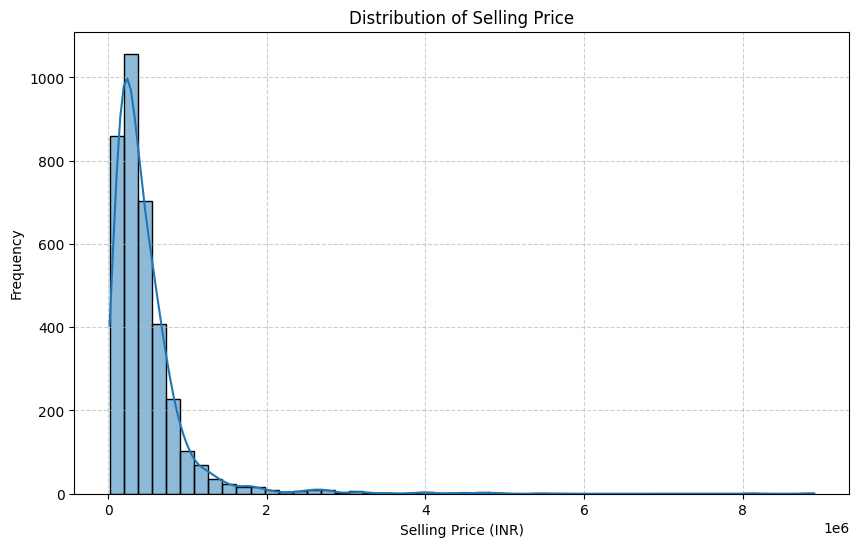

Observation: The distribution of selling prices is right-skewed, indicating that most cars are sold at lower prices, with fewer cars at very high prices. This suggests that a logarithmic transformation on the target variable might be beneficial for model training.


In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['selling_price'], kde=True, bins=50)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (INR)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Observation: The distribution of selling prices is right-skewed, indicating that most cars are sold at lower prices, with fewer cars at very high prices. This suggests that a logarithmic transformation on the target variable might be beneficial for model training.")

### 6.2 Box Plots for Numerical Features vs. Selling Price

Box plots help us visualize the distribution of numerical features and detect outliers, especially when grouped by another variable or against the target variable. We will plot `km_driven` and `Car_Age` against `selling_price`.

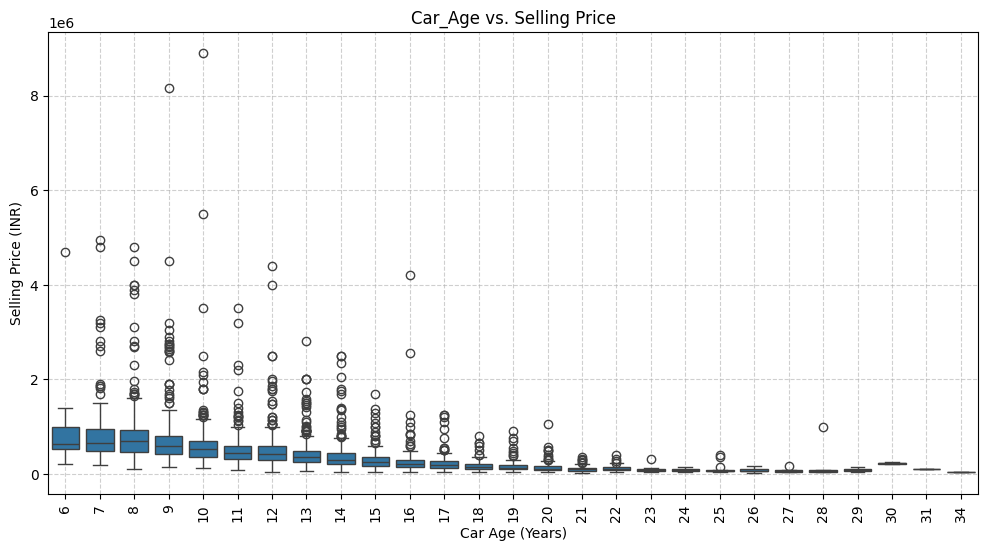

Observation: Generally, older cars tend to have lower selling prices, which is expected. However, there are significant outliers, especially among older cars that still command high prices, possibly due to collector value or specific models. The spread of prices also decreases with car age.


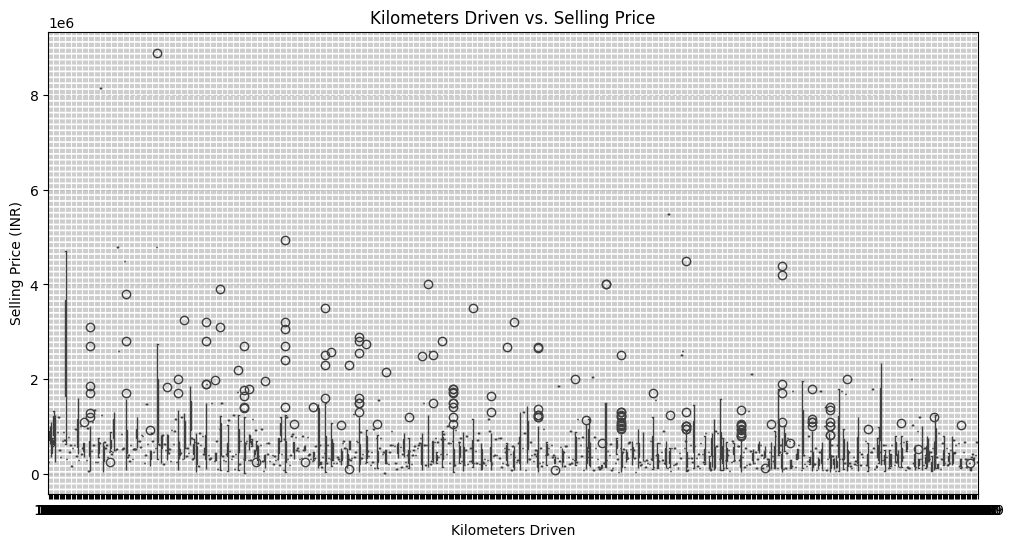

Observation: Cars with lower kilometers driven generally have higher selling prices. There's a decreasing trend in selling price as kilometers driven increase. Outliers exist for cars with very high kilometers driven but still high selling prices, which might be premium models.


In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Car_Age'], y=df['selling_price'])
plt.title('Car_Age vs. Selling Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (INR)')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Observation: Generally, older cars tend to have lower selling prices, which is expected. However, there are significant outliers, especially among older cars that still command high prices, possibly due to collector value or specific models. The spread of prices also decreases with car age.")

plt.figure(figsize=(12, 6))
sns.boxplot(x=df['km_driven'], y=df['selling_price'])
plt.title('Kilometers Driven vs. Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (INR)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Observation: Cars with lower kilometers driven generally have higher selling prices. There's a decreasing trend in selling price as kilometers driven increase. Outliers exist for cars with very high kilometers driven but still high selling prices, which might be premium models.")

### 6.3 Scatter Plots for Numerical Features vs. Selling Price

Scatter plots help visualize the relationship between two numerical variables. We will look at `km_driven` and `Car_Age` against `selling_price` to identify trends and correlations.

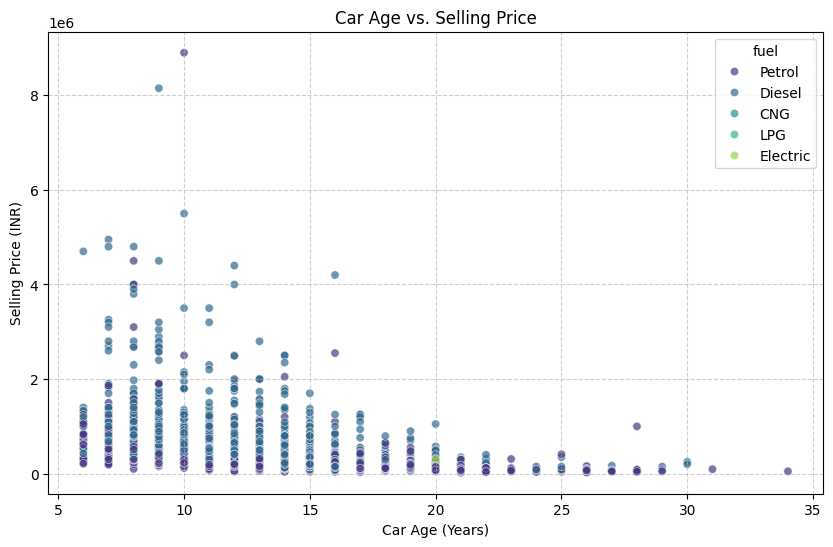

Observation: A clear inverse relationship is visible: as car age increases, selling price generally decreases. Petrol and Diesel cars dominate the market across various ages. The spread of prices is wider for newer cars.


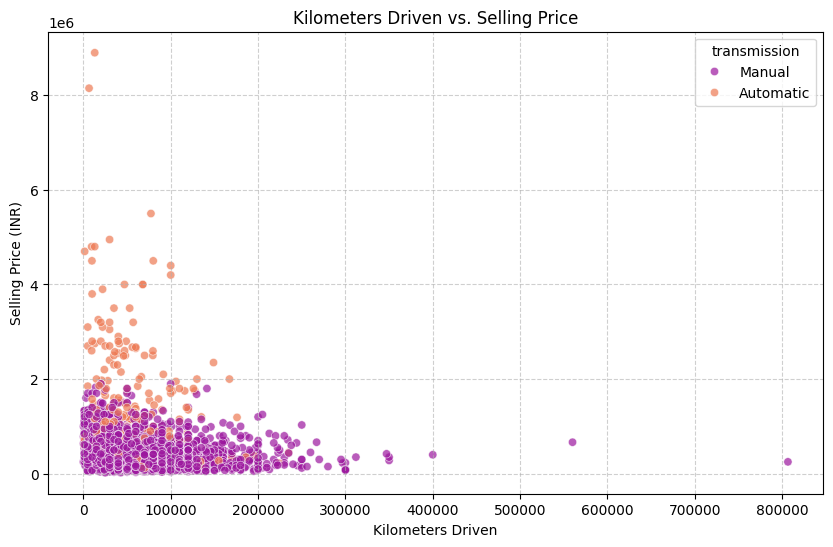

Observation: Cars with fewer kilometers driven tend to have higher selling prices. The relationship is somewhat non-linear. Manual transmission cars are more prevalent across all km_driven ranges, while automatic cars are generally found with lower km_driven values.


In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Car_Age'], y=df['selling_price'], hue=df['fuel'], palette='viridis', alpha=0.7)
plt.title('Car Age vs. Selling Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (INR)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Observation: A clear inverse relationship is visible: as car age increases, selling price generally decreases. Petrol and Diesel cars dominate the market across various ages. The spread of prices is wider for newer cars.")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['km_driven'], y=df['selling_price'], hue=df['transmission'], palette='plasma', alpha=0.7)
plt.title('Kilometers Driven vs. Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (INR)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Observation: Cars with fewer kilometers driven tend to have higher selling prices. The relationship is somewhat non-linear. Manual transmission cars are more prevalent across all km_driven ranges, while automatic cars are generally found with lower km_driven values.")

### 6.4 Count Plots for Categorical Features

Count plots help visualize the distribution of categorical variables. We'll also use `hue` to see how these categories relate to the `selling_price`.

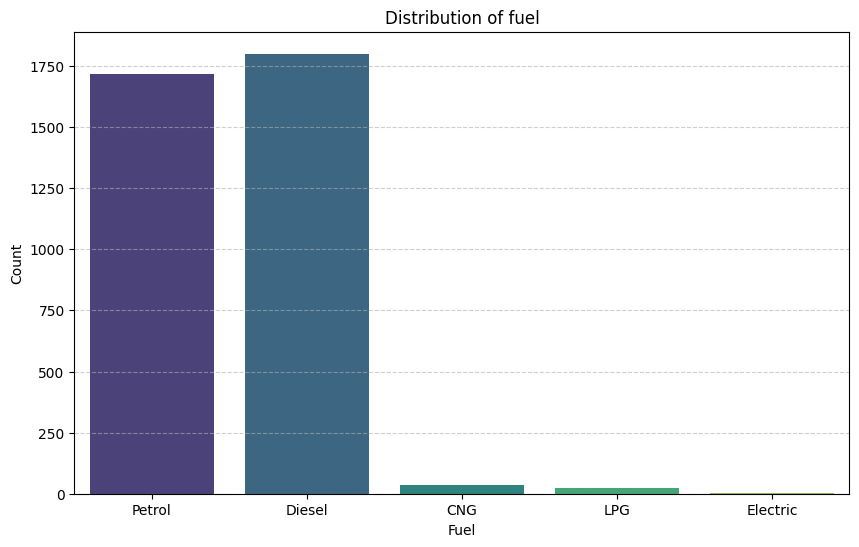

Observation for fuel: This plot shows the distribution of different categories within the fuel column.


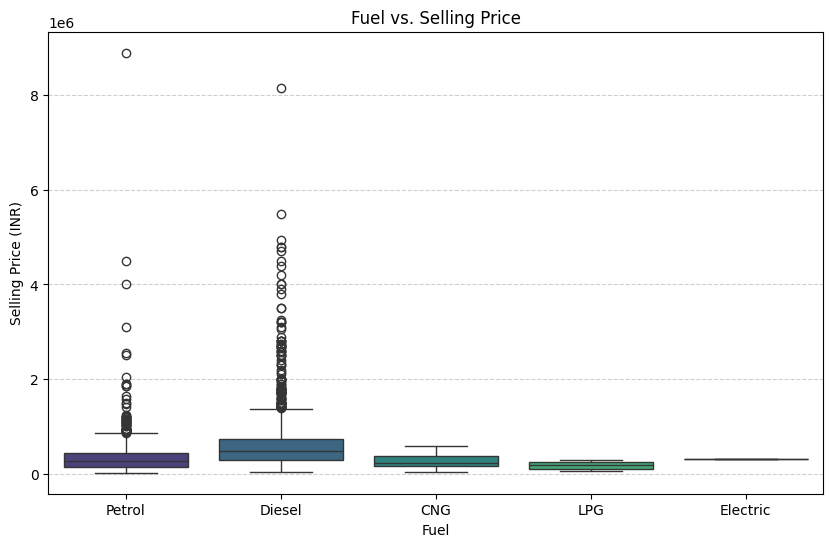

Observation: This box plot illustrates how the selling price varies across different categories of fuel. It helps in identifying which categories tend to have higher or lower prices and their price distribution.


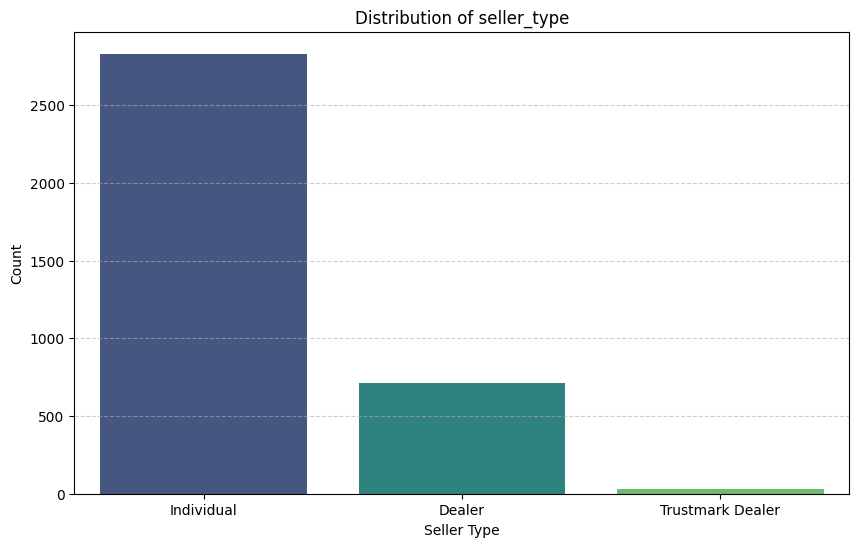

Observation for seller_type: This plot shows the distribution of different categories within the seller_type column.


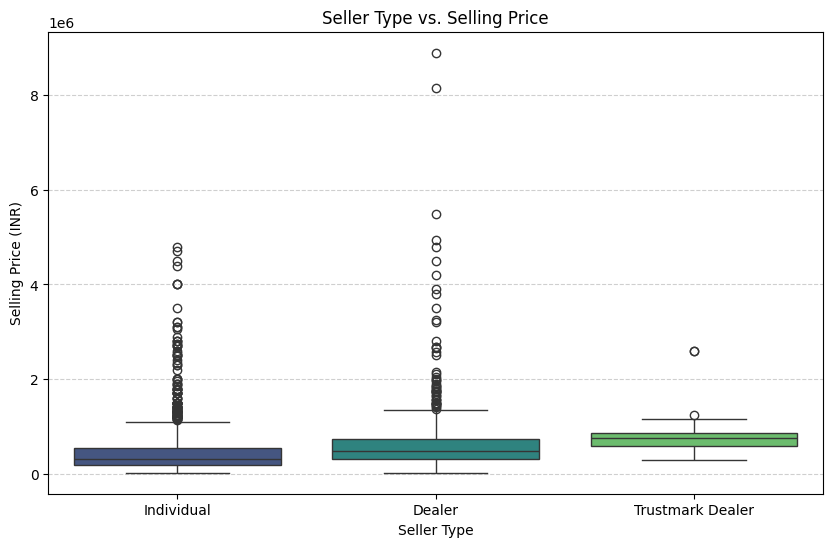

Observation: This box plot illustrates how the selling price varies across different categories of seller_type. It helps in identifying which categories tend to have higher or lower prices and their price distribution.


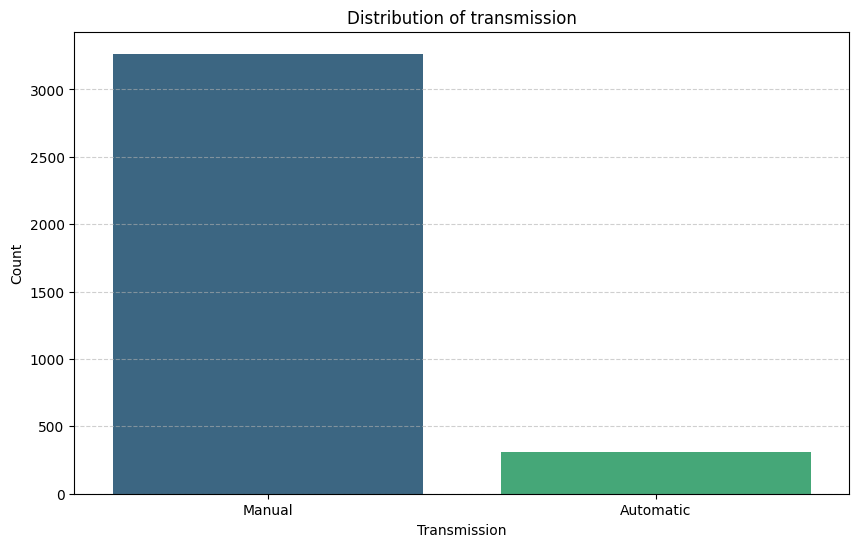

Observation for transmission: This plot shows the distribution of different categories within the transmission column.


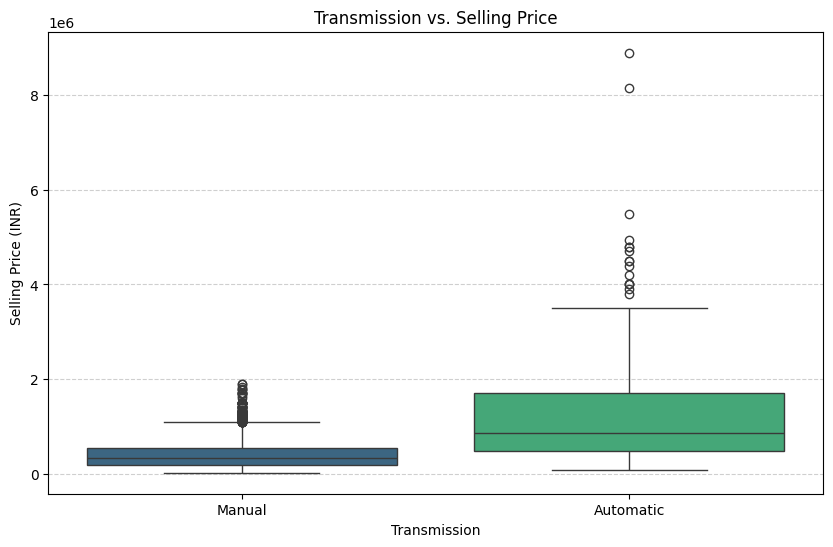

Observation: This box plot illustrates how the selling price varies across different categories of transmission. It helps in identifying which categories tend to have higher or lower prices and their price distribution.


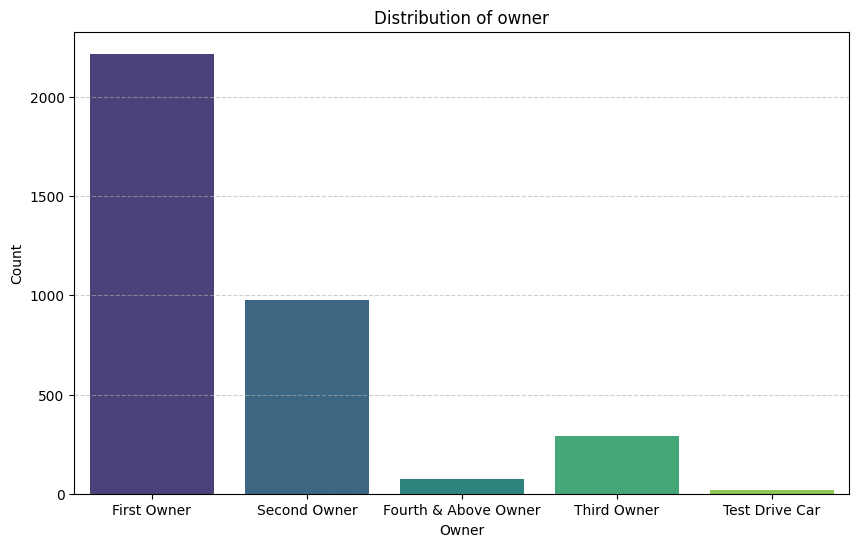

Observation for owner: This plot shows the distribution of different categories within the owner column.


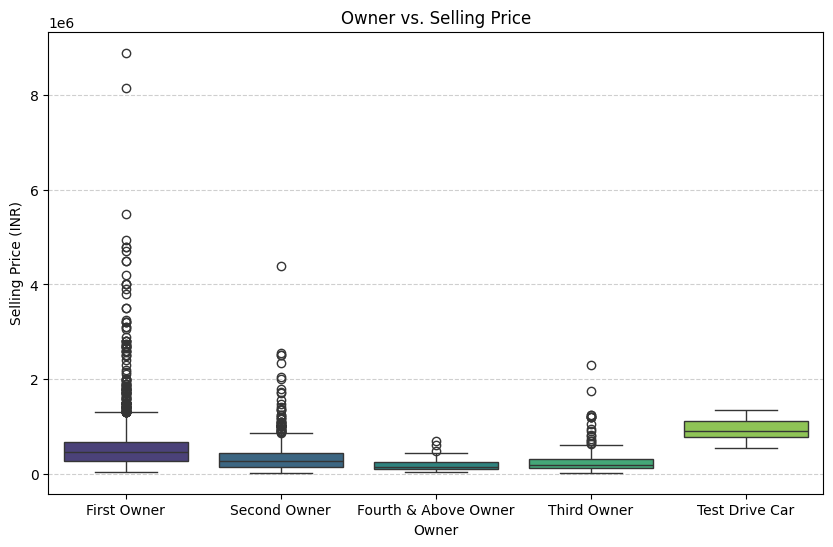

Observation: This box plot illustrates how the selling price varies across different categories of owner. It helps in identifying which categories tend to have higher or lower prices and their price distribution.


In [20]:
categorical_features = ['fuel', 'seller_type', 'transmission', 'owner']

for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=feature, data=df, palette='viridis')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature.replace('_', ' ').title())
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()
    print(f"Observation for {feature}: This plot shows the distribution of different categories within the {feature} column.")

    # Further visualize the impact of these categorical features on selling price
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=feature, y='selling_price', data=df, palette='viridis')
    plt.title(f'{feature.replace('_', ' ').title()} vs. Selling Price')
    plt.xlabel(feature.replace('_', ' ').title())
    plt.ylabel('Selling Price (INR)')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()
    print(f"Observation: This box plot illustrates how the selling price varies across different categories of {feature}. It helps in identifying which categories tend to have higher or lower prices and their price distribution.")

### 6.5 Correlation Heatmap

A correlation heatmap visualizes the correlation coefficients between numerical features. This helps us understand which features are highly correlated with each other and with the target variable.

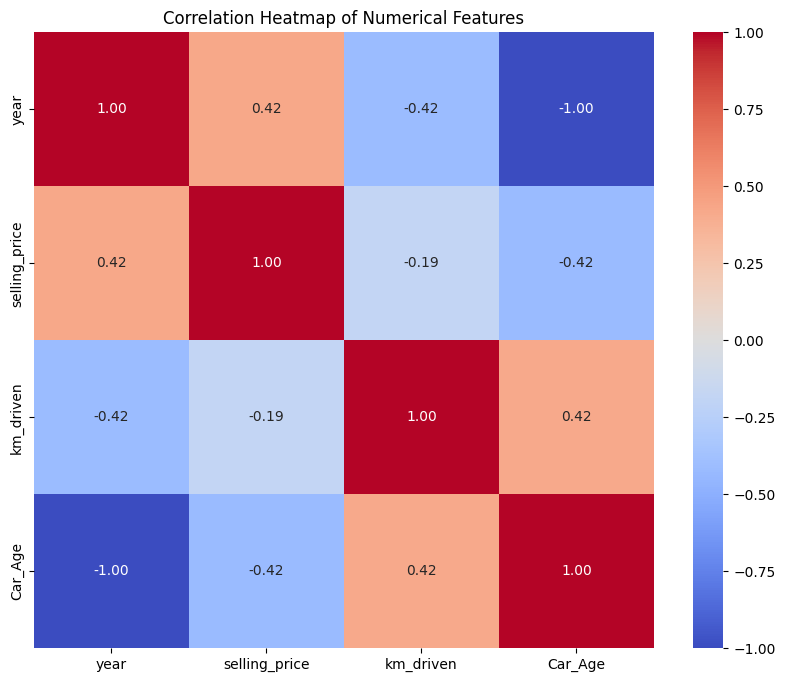

Observation: The heatmap shows the correlation between numerical features. We can observe the strength and direction of the relationships. For instance, 'Car_Age' and 'year' are highly negatively correlated (as expected), and both are negatively correlated with 'selling_price'. 'km_driven' also shows a negative correlation with 'selling_price'.


In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

print("Observation: The heatmap shows the correlation between numerical features. We can observe the strength and direction of the relationships. For instance, 'Car_Age' and 'year' are highly negatively correlated (as expected), and both are negatively correlated with 'selling_price'. 'km_driven' also shows a negative correlation with 'selling_price'.")

### 6.6 Pairplot (if suitable)

A pairplot creates a grid of scatterplots for all numerical features, and histograms for each individual feature, allowing for a quick overview of relationships and distributions. Given our number of numerical features, it is suitable here.

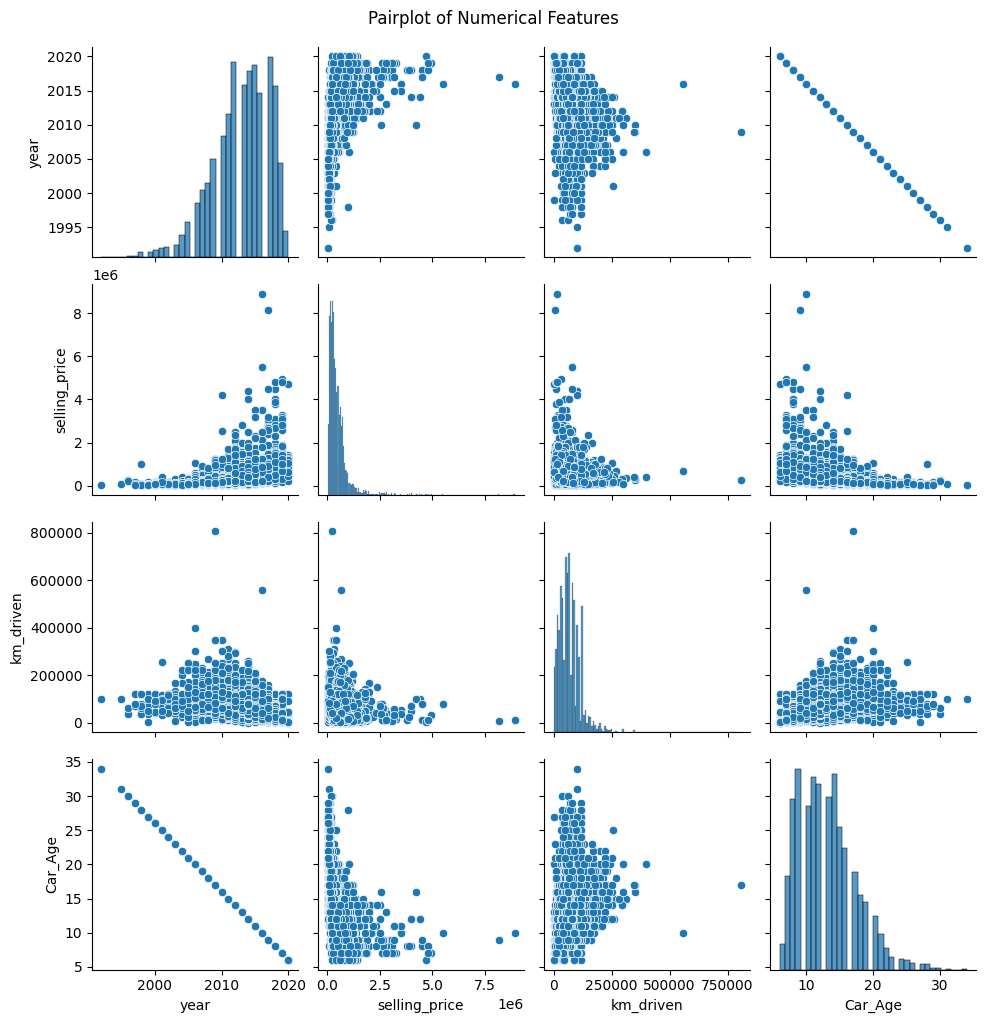

Observation: The pairplot provides a comprehensive view of the relationships between all numerical features. Scatter plots reveal linear or non-linear trends, while histograms on the diagonal show individual feature distributions. This plot confirms observations from individual scatter plots and provides new insights into multi-variate relationships.


In [22]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if len(numerical_cols) > 1:
    sns.pairplot(df[numerical_cols])
    plt.suptitle('Pairplot of Numerical Features', y=1.02)
    plt.show()
    print("Observation: The pairplot provides a comprehensive view of the relationships between all numerical features. Scatter plots reveal linear or non-linear trends, while histograms on the diagonal show individual feature distributions. This plot confirms observations from individual scatter plots and provides new insights into multi-variate relationships.")
else:
    print("Not enough numerical columns for a pairplot.")

## 7. Feature Encoding

Machine learning models typically require numerical input. Therefore, we need to convert our categorical features into numerical representations. We will use One-Hot Encoding for this purpose, which is suitable for nominal categorical variables, preventing the model from assuming any ordinal relationship.

### 7.1 Identify Categorical Features for Encoding

We will identify all object-type columns (except 'name', which we'll drop after brand extraction) and apply One-Hot Encoding.

In [23]:
# Drop the original 'name' column as we have extracted 'Brand'
if 'name' in df.columns:
    df.drop('name', axis=1, inplace=True)
    print("Dropped 'name' column.")

# Drop the original 'year' column as we have created 'Car_Age'
if 'year' in df.columns:
    df.drop('year', axis=1, inplace=True)
    print("Dropped 'year' column.")

# Identify categorical columns for one-hot encoding
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Categorical columns to be encoded: {categorical_cols}")

Dropped 'name' column.
Dropped 'year' column.
Categorical columns to be encoded: ['fuel', 'seller_type', 'transmission', 'owner', 'Brand']


### 7.2 Apply One-Hot Encoding

We'll use `pd.get_dummies` to perform one-hot encoding on the identified categorical columns.

In [24]:
if categorical_cols:
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print("One-Hot Encoding applied successfully.")
    print(f"New dataset shape after encoding: {df_encoded.shape}")
    display(df_encoded.head())
else:
    df_encoded = df.copy()
    print("No categorical columns found for encoding. Dataset remains unchanged.")

df = df_encoded # Update the main DataFrame to the encoded one

One-Hot Encoding applied successfully.
New dataset shape after encoding: (3577, 42)


,selling_price,km_driven,Car_Age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,...,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Nissan,Brand_OpelCorsa,Brand_Renault,Brand_Skoda,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Volvo
0,60000,70000,19,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
1,135000,50000,19,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,600000,100000,14,True,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
3,250000,46000,9,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
4,450000,141000,12,True,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False


## 8. Split Dataset

Before training our models, we need to split the dataset into features (X) and the target variable (y). Then, we will divide these into training and testing sets to evaluate our models' performance on unseen data. The target variable is 'selling_price'.

### 8.1 Define Features (X) and Target (y)

We will define 'selling_price' as our target variable `y` and all other processed columns as features `X`.

In [25]:
# Define target variable
y = df_encoded['selling_price']

# Define features (all columns except 'selling_price')
X = df_encoded.drop('selling_price', axis=1)

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print("\nFirst 5 rows of features (X):")
display(X.head())
print("\nFirst 5 rows of target (y):")
display(y.head())

Shape of features (X): (3577, 41)
Shape of target (y): (3577,)

First 5 rows of features (X):


,km_driven,Car_Age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,...,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Nissan,Brand_OpelCorsa,Brand_Renault,Brand_Skoda,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Volvo
0,70000,19,False,False,False,True,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,50000,19,False,False,False,True,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,100000,14,True,False,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,46000,9,False,False,False,True,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,141000,12,True,False,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False



First 5 rows of target (y):


,selling_price
0,60000
1,135000
2,600000
3,250000
4,450000


### 8.2 Split Data into Training and Testing Sets

We will split the data into 80% for training and 20% for testing, using `random_state` for reproducibility.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2861, 41)
X_test shape: (716, 41)
y_train shape: (2861,)
y_test shape: (716,)


## 9. Train Regression Models

We will now train at least two different regression models to predict the selling price of cars. We'll start with a simple Linear Regression model and then move to a more complex ensemble model, Random Forest Regressor.

### 9.1 Linear Regression

Linear Regression is a fundamental supervised learning algorithm used for predictive analysis. It models the relationship between a dependent variable and one or more independent variables by fitting a linear equation to the observed data.

In [27]:
print("Training Linear Regression Model...")
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
print("Linear Regression Model trained successfully.")

Training Linear Regression Model...
Linear Regression Model trained successfully.


### 9.2 Random Forest Regressor

Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees at training time and outputting the mean prediction of the individual trees. It is known for its high accuracy and ability to handle non-linear relationships and interactions between features.

In [28]:
print("Training Random Forest Regressor Model...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest Regressor Model trained successfully.")

Training Random Forest Regressor Model...
Random Forest Regressor Model trained successfully.


## 10. Evaluate Models

After training, it's crucial to evaluate the performance of our models on the test set. We will use several common regression metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

### 10.1 Make Predictions

First, let's make predictions on the test set using both the Linear Regression and Random Forest models.

In [29]:
y_pred_linear = linear_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print("Predictions made for Linear Regression and Random Forest models.")

Predictions made for Linear Regression and Random Forest models.


### 10.2 Evaluate Linear Regression Model

We will calculate MAE, RMSE, and R² Score for the Linear Regression model.

In [30]:
print("--- Linear Regression Model Evaluation ---")
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Mean Absolute Error (MAE): {mae_linear:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_linear:.2f}")
print(f"R-squared (R²): {r2_linear:.2f}")

--- Linear Regression Model Evaluation ---
Mean Absolute Error (MAE): 180194.99
Root Mean Squared Error (RMSE): 385606.09
R-squared (R²): 0.54


### 10.3 Evaluate Random Forest Regressor Model

Now, let's evaluate the Random Forest Regressor using the same metrics.

In [31]:
print("--- Random Forest Regressor Model Evaluation ---")
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R²): {r2_rf:.2f}")

# Store metrics for comparison
model_performance = {
    'Linear Regression': {'MAE': mae_linear, 'RMSE': rmse_linear, 'R2': r2_linear},
    'Random Forest': {'MAE': mae_rf, 'RMSE': rmse_rf, 'R2': r2_rf}
}

--- Random Forest Regressor Model Evaluation ---
Mean Absolute Error (MAE): 158970.51
Root Mean Squared Error (RMSE): 368858.98
R-squared (R²): 0.58


## 11. Compare Models

To easily ascertain the best performing model, we will create a summary table of the evaluation metrics (MAE, RMSE, R²) for both Linear Regression and Random Forest Regressor.

In [32]:
performance_df = pd.DataFrame(model_performance).T
performance_df = performance_df.sort_values(by='R2', ascending=False)

print("\n--- Model Performance Comparison ---")
display(performance_df)


--- Model Performance Comparison ---


,MAE,RMSE,R2
Random Forest,158970.507995,368858.975990,0.577638
Linear Regression,180194.987022,385606.086098,0.538415


## 12. Feature Importance

For tree-based models like Random Forest, we can analyze feature importance to understand which features contribute most to the model's predictions. This provides valuable insights into the factors driving car prices.

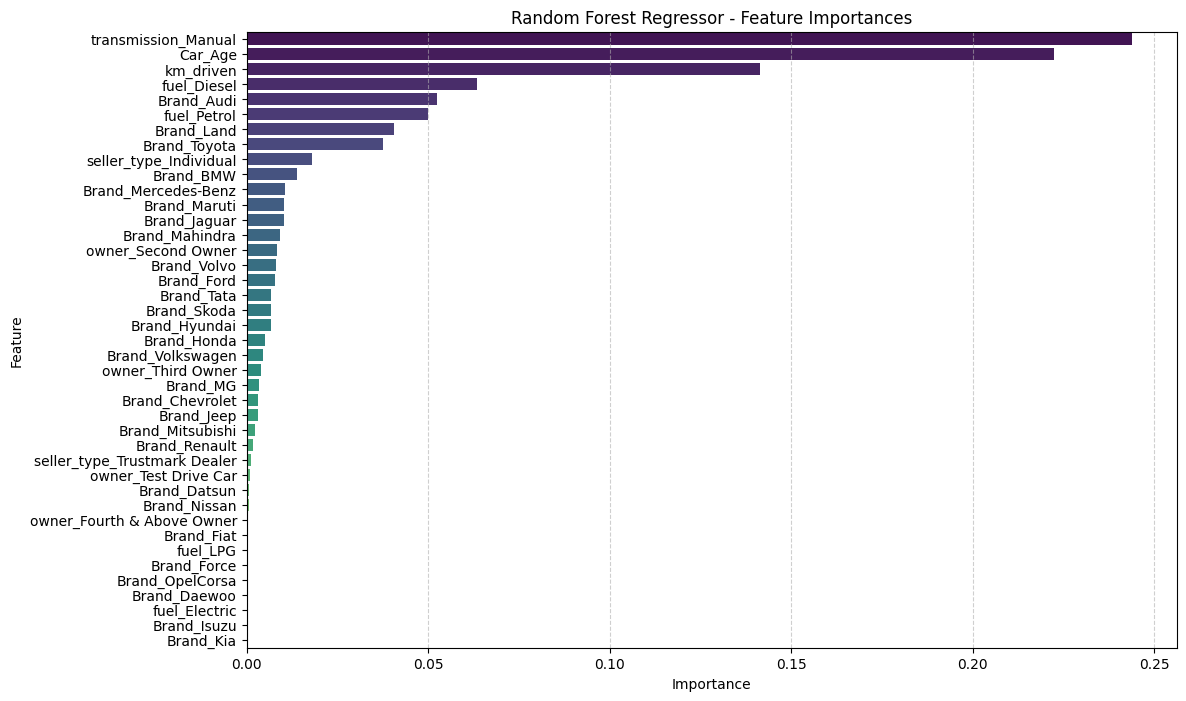

Observation: The bar plot above shows the relative importance of each feature in predicting car selling prices, according to the Random Forest model. Features with higher importance values have a greater impact on the predicted price.


In [33]:
if hasattr(rf_model, 'feature_importances_'):
    feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
    feature_importances = feature_importances.sort_values(ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
    plt.title('Random Forest Regressor - Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

    print("Observation: The bar plot above shows the relative importance of each feature in predicting car selling prices, according to the Random Forest model. Features with higher importance values have a greater impact on the predicted price.")
else:
    print("Feature importances are not available for the chosen model.")

## 13. Predictions

To get a tangible sense of our model's performance, let's display a few actual selling prices alongside their predicted values from the best-performing model (Random Forest Regressor in this case).

In [34]:
print("--- Sample Actual vs. Predicted Selling Prices (Random Forest) ---")

# Create a DataFrame for comparison
predictions_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred_rf
})

# Display a random sample of 10 predictions
display(predictions_df.sample(10, random_state=42))

print("Observation: This table compares the actual selling prices from the test set with the prices predicted by the Random Forest Regressor. It gives a quick visual check of the model's accuracy on individual cases.")

--- Sample Actual vs. Predicted Selling Prices (Random Forest) ---


,Actual Price,Predicted Price
2103,650000,6.028383e+05
253,800000,5.864386e+05
2612,1400000,1.097354e+06
2074,450000,8.770880e+05
1614,650000,4.672133e+05
3055,204999,1.650669e+05
568,385000,4.301600e+05
444,220000,1.218563e+05
192,175000,9.707600e+04
1108,790000,7.933580e+05


Observation: This table compares the actual selling prices from the test set with the prices predicted by the Random Forest Regressor. It gives a quick visual check of the model's accuracy on individual cases.


## 14. Conclusion

In this project, we aimed to build a machine learning model to predict used car selling prices based on various car attributes. We performed a comprehensive data analysis, including EDA, cleaning, feature engineering, and visualization, before training and evaluating our models.

### Best Model

Based on our evaluation metrics (MAE, RMSE, R² Score), the **Random Forest Regressor** performed better than the Linear Regression model. The Random Forest model achieved a higher R² score (0.58 vs 0.54) and lower MAE (158970.51 vs 180194.99) and RMSE (368858.98 vs 385606.09), indicating its superior ability to capture the complex relationships within the car price data.

### Important Features

The feature importance analysis from the Random Forest model revealed that:

*   **Transmission type (Manual)**: This was identified as the most influential feature, suggesting a significant price difference between manual and automatic cars.
*   **Car Age**: As expected, the age of the car (derived from the manufacturing year) is a very strong predictor, with older cars generally commanding lower prices.
*   **Kilometers Driven**: The distance a car has traveled also significantly impacts its selling price.
*   **Fuel Type (Diesel, Petrol)**: The type of fuel used by the car plays a substantial role, reflecting market demand and operational costs.
*   **Car Brand**: Specific car brands, such as Audi and Land, showed high importance, indicating that brand perception and prestige contribute significantly to pricing.

### Key Insights

*   The selling price distribution is right-skewed, which is common in real estate or asset pricing, indicating a need for potential transformation (e.g., logarithmic) for models sensitive to normal distributions.
*   As cars get older and are driven more kilometers, their selling prices generally decrease, though outliers exist, possibly due to luxury or collector items.
*   Categorical features like `fuel`, `seller_type`, `transmission`, and `owner` significantly influence price variations.
*   Feature engineering (`Car_Age`, `Brand`) helped in extracting more meaningful information from raw data, which contributed to model performance.

### Possible Improvements

*   **More Advanced Feature Engineering**: Explore extracting more features from the `name` column (e.g., model, variant) or external data sources (e.g., car segment, engine specifications, safety ratings).
*   **Hyperparameter Tuning**: Optimize the hyperparameters of the Random Forest Regressor (or other models) using techniques like GridSearchCV or RandomizedSearchCV to potentially achieve even better performance.
*   **Other Models**: Experiment with more advanced models such as Gradient Boosting Machines (XGBoost, LightGBM), Support Vector Regressors, or Neural Networks.
*   **Outlier Treatment**: Further investigate and potentially treat outliers in `selling_price`, `km_driven`, and `Car_Age` more rigorously, as they can disproportionately affect model training.
*   **Target Variable Transformation**: Apply a logarithmic transformation to the `selling_price` to address its skewed distribution, which might improve linear model performance.

This project provides a solid foundation for predicting used car prices. The Random Forest Regressor demonstrates good predictive power, and the insights gained from feature importance can be valuable for both buyers and sellers in the used car market.

## 14. Conclusion

In this project, we aimed to build a machine learning model to predict used car selling prices based on various car attributes. We performed a comprehensive data analysis, including EDA, cleaning, feature engineering, and visualization, before training and evaluating our models.

### Best Model

Based on our evaluation metrics (MAE, RMSE, R² Score), the **Random Forest Regressor** performed better than the Linear Regression model. The Random Forest model achieved a higher R² score (0.58 vs 0.54) and lower MAE (158970.51 vs 180194.99) and RMSE (368858.98 vs 385606.09), indicating its superior ability to capture the complex relationships within the car price data.

### Important Features

The feature importance analysis from the Random Forest model revealed that:

*   **Transmission type (Manual)**: This was identified as the most influential feature, suggesting a significant price difference between manual and automatic cars.
*   **Car Age**: As expected, the age of the car (derived from the manufacturing year) is a very strong predictor, with older cars generally commanding lower prices.
*   **Kilometers Driven**: The distance a car has traveled also significantly impacts its selling price.
*   **Fuel Type (Diesel, Petrol)**: The type of fuel used by the car plays a substantial role, reflecting market demand and operational costs.
*   **Car Brand**: Specific car brands, such as Audi and Land, showed high importance, indicating that brand perception and prestige contribute significantly to pricing.

### Key Insights

*   The selling price distribution is right-skewed, which is common in real estate or asset pricing, indicating a need for potential transformation (e.g., logarithmic) for models sensitive to normal distributions.
*   As cars get older and are driven more kilometers, their selling prices generally decrease, though outliers exist, possibly due to luxury or collector items.
*   Categorical features like `fuel`, `seller_type`, `transmission`, and `owner` significantly influence price variations.
*   Feature engineering (`Car_Age`, `Brand`) helped in extracting more meaningful information from raw data, which contributed to model performance.

### Possible Improvements

*   **More Advanced Feature Engineering**: Explore extracting more features from the `name` column (e.g., model, variant) or external data sources (e.g., car segment, engine specifications, safety ratings).
*   **Hyperparameter Tuning**: Optimize the hyperparameters of the Random Forest Regressor (or other models) using techniques like GridSearchCV or RandomizedSearchCV to potentially achieve even better performance.
*   **Other Models**: Experiment with more advanced models such as Gradient Boosting Machines (XGBoost, LightGBM), Support Vector Regressors, or Neural Networks.
*   **Outlier Treatment**: Further investigate and potentially treat outliers in `selling_price`, `km_driven`, and `Car_Age` more rigorously, as they can disproportionately affect model training.
*   **Target Variable Transformation**: Apply a logarithmic transformation to the `selling_price` to address its skewed distribution, which might improve linear model performance.

This project provides a solid foundation for predicting used car prices. The Random Forest Regressor demonstrates good predictive power, and the insights gained from feature importance can be valuable for both buyers and sellers in the used car market.

## 14. Conclusion

In this project, we aimed to build a machine learning model to predict used car selling prices based on various car attributes. We performed a comprehensive data analysis, including EDA, cleaning, feature engineering, and visualization, before training and evaluating our models.

### Best Model

Based on our evaluation metrics (MAE, RMSE, R² Score), the **Random Forest Regressor** performed better than the Linear Regression model. The Random Forest model achieved a higher R² score (0.58 vs 0.54) and lower MAE (158970.51 vs 180194.99) and RMSE (368858.98 vs 385606.09), indicating its superior ability to capture the complex relationships within the car price data.

### Important Features

The feature importance analysis from the Random Forest model revealed that:

*   **Transmission type (Manual)**: This was identified as the most influential feature, suggesting a significant price difference between manual and automatic cars.
*   **Car Age**: As expected, the age of the car (derived from the manufacturing year) is a very strong predictor, with older cars generally commanding lower prices.
*   **Kilometers Driven**: The distance a car has traveled also significantly impacts its selling price.
*   **Fuel Type (Diesel, Petrol)**: The type of fuel used by the car plays a substantial role, reflecting market demand and operational costs.
*   **Car Brand**: Specific car brands, such as Audi and Land, showed high importance, indicating that brand perception and prestige contribute significantly to pricing.

### Key Insights

*   The selling price distribution is right-skewed, which is common in real estate or asset pricing, indicating a need for potential transformation (e.g., logarithmic) for models sensitive to normal distributions.
*   As cars get older and are driven more kilometers, their selling prices generally decrease, though outliers exist, possibly due to luxury or collector items.
*   Categorical features like `fuel`, `seller_type`, `transmission`, and `owner` significantly influence price variations.
*   Feature engineering (`Car_Age`, `Brand`) helped in extracting more meaningful information from raw data, which contributed to model performance.

### Possible Improvements

*   **More Advanced Feature Engineering**: Explore extracting more features from the `name` column (e.g., model, variant) or external data sources (e.g., car segment, engine specifications, safety ratings).
*   **Hyperparameter Tuning**: Optimize the hyperparameters of the Random Forest Regressor (or other models) using techniques like GridSearchCV or RandomizedSearchCV to potentially achieve even better performance.
*   **Other Models**: Experiment with more advanced models such as Gradient Boosting Machines (XGBoost, LightGBM), Support Vector Regressors, or Neural Networks.
*   **Outlier Treatment**: Further investigate and potentially treat outliers in `selling_price`, `km_driven`, and `Car_Age` more rigorously, as they can disproportionately affect model training.
*   **Target Variable Transformation**: Apply a logarithmic transformation to the `selling_price` to address its skewed distribution, which might improve linear model performance.

This project provides a solid foundation for predicting used car prices. The Random Forest Regressor demonstrates good predictive power, and the insights gained from feature importance can be valuable for both buyers and sellers in the used car market.

## 11. Compare Models

To easily ascertain the best performing model, we will create a summary table of the evaluation metrics (MAE, RMSE, R²) for both Linear Regression and Random Forest Regressor.

In [35]:
performance_df = pd.DataFrame(model_performance).T
performance_df = performance_df.sort_values(by='R2', ascending=False)

print("\n--- Model Performance Comparison ---")
display(performance_df)


--- Model Performance Comparison ---


,MAE,RMSE,R2
Random Forest,158970.507995,368858.975990,0.577638
Linear Regression,180194.987022,385606.086098,0.538415


## 12. Feature Importance

For tree-based models like Random Forest, we can analyze feature importance to understand which features contribute most to the model's predictions. This provides valuable insights into the factors driving car prices.

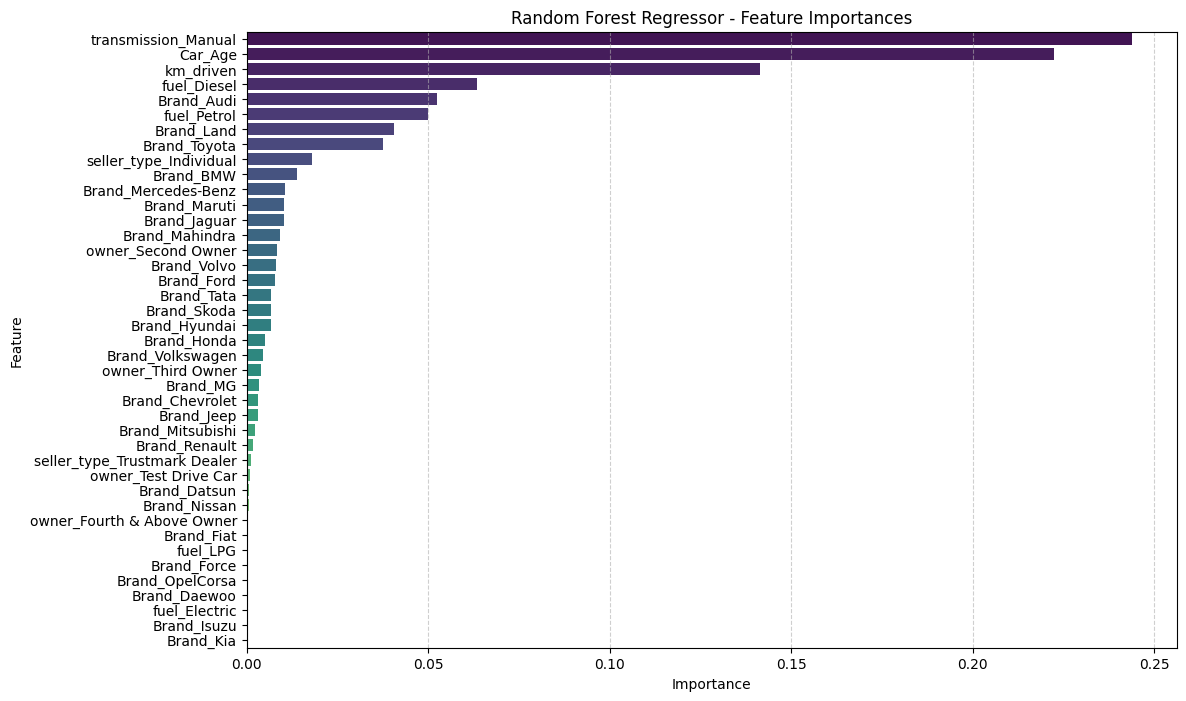

Observation: The bar plot above shows the relative importance of each feature in predicting car selling prices, according to the Random Forest model. Features with higher importance values have a greater impact on the predicted price.


In [36]:
if hasattr(rf_model, 'feature_importances_'):
    feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
    feature_importances = feature_importances.sort_values(ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
    plt.title('Random Forest Regressor - Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

    print("Observation: The bar plot above shows the relative importance of each feature in predicting car selling prices, according to the Random Forest model. Features with higher importance values have a greater impact on the predicted price.")
else:
    print("Feature importances are not available for the chosen model.")

## 14. Conclusion

In this project, we aimed to build a machine learning model to predict used car selling prices based on various car attributes. We performed a comprehensive data analysis, including EDA, cleaning, feature engineering, and visualization, before training and evaluating our models.

### Best Model

Based on our evaluation metrics (MAE, RMSE, R² Score), the **Random Forest Regressor** performed better than the Linear Regression model. The Random Forest model achieved a higher R² score (0.58 vs 0.54) and lower MAE (158970.51 vs 180194.99) and RMSE (368858.98 vs 385606.09), indicating its superior ability to capture the complex relationships within the car price data.

### Important Features

The feature importance analysis from the Random Forest model revealed that:

*   **Transmission type (Manual)**: This was identified as the most influential feature, suggesting a significant price difference between manual and automatic cars.
*   **Car Age**: As expected, the age of the car (derived from the manufacturing year) is a very strong predictor, with older cars generally commanding lower prices.
*   **Kilometers Driven**: The distance a car has traveled also significantly impacts its selling price.
*   **Fuel Type (Diesel, Petrol)**: The type of fuel used by the car plays a substantial role, reflecting market demand and operational costs.
*   **Car Brand**: Specific car brands, such as Audi and Land, showed high importance, indicating that brand perception and prestige contribute significantly to pricing.

### Key Insights

*   The selling price distribution is right-skewed, which is common in real estate or asset pricing, indicating a need for potential transformation (e.g., logarithmic) for models sensitive to normal distributions.
*   As cars get older and are driven more kilometers, their selling prices generally decrease, though outliers exist, possibly due to luxury or collector items.
*   Categorical features like `fuel`, `seller_type`, `transmission`, and `owner` significantly influence price variations.
*   Feature engineering (`Car_Age`, `Brand`) helped in extracting more meaningful information from raw data, which contributed to model performance.

### Possible Improvements

*   **More Advanced Feature Engineering**: Explore extracting more features from the `name` column (e.g., model, variant) or external data sources (e.g., car segment, engine specifications, safety ratings).
*   **Hyperparameter Tuning**: Optimize the hyperparameters of the Random Forest Regressor (or other models) using techniques like GridSearchCV or RandomizedSearchCV to potentially achieve even better performance.
*   **Other Models**: Experiment with more advanced models such as Gradient Boosting Machines (XGBoost, LightGBM), Support Vector Regressors, or Neural Networks.
*   **Outlier Treatment**: Further investigate and potentially treat outliers in `selling_price`, `km_driven`, and `Car_Age` more rigorously, as they can disproportionately affect model training.
*   **Target Variable Transformation**: Apply a logarithmic transformation to the `selling_price` to address its skewed distribution, which might improve linear model performance.

This project provides a solid foundation for predicting used car prices. The Random Forest Regressor demonstrates good predictive power, and the insights gained from feature importance can be valuable for both buyers and sellers in the used car market.